# 0. Setup Python

First, let's import a few common modules and ensure MatplotLib plots figures inline. We also check that Python 3.5 or later is installed (although Python 2.x may work, it is deprecated so we strongly recommend you use Python 3 instead), as well as Scikit-Learn ≥0.20.

In [2]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"
print(sklearn.__version__)

# Common imports
import numpy as np
import pandas as pd
import os

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt


1.8.0


# 1. The problem we want to solve
Predict future temperatures in Brussels in **winter** based on temperature registrations since 1883 using polynomial regression with regularization.
- Find the optimal polynomial degree
- Use lasso regression and determine the optimal $\alpha$
- Determine the RMSE for the optimal model (avoid data leakage).
- Visualize the new model
- Which prediction for the temperature in 2100 do you get? 
- It it more or less than the prediction you get with a pure linear regression with degree 1? Explain. 

# 2. Get the Data

## Download the Data

Governments and major cities provides lots op open data that can be freely used for analyses:
- data.vlaanderen.be: Flemish government
- data.gov.be: Belgian government
- data.gent.be: city of Gent
- ...

We find average seasonal temperatures in Ukkel (Brussels) at https://www.vlaanderen.be/DataCatalogRecord/72ff6930-87e4-38c4-9a27-d3ddda385637. 

The download link for the winter data (as a csv file) is:
https://www.vmm.be/klimaat/seizoensgemiddelde-temperatuur/winter-temp/@@download/csv

Download the file and place it in a subdirectory "datasets" from directory where this notebook resides. 

Read and explore the dataset in a pandas dataframe:

In [3]:
csv_path = 'datasets/winter temp.csv'
temperatures = pd.read_csv(csv_path)
temperatures.head(10)


,jaar,95 %-betrouwbaarheidsinterval van punten op de trendlijn,gemiddelde van de gemeten waarden,trendlijn
0,1834,"(3.239, 1.063)",5.4,2.151
1,1835,"(3.16, 1.11)",4.2,2.135
2,1836,"(3.084, 1.152)",2.0,2.118
3,1837,"(3.015, 1.189)",2.8,2.102
4,1838,"(2.951, 1.223)",-1.1,2.087
5,1839,"(2.891, 1.253)",2.3,2.072
6,1840,"(2.836, 1.28)",3.2,2.058
7,1841,"(2.787, 1.305)",-0.9,2.046
8,1842,"(2.745, 1.325)",1.6,2.035
9,1843,"(2.707, 1.343)",2.6,2.025


We need only the column "jaar" and "gemiddelde van de gemeten waarden". 

In [4]:
temperatures = temperatures[['jaar','gemiddelde van de gemeten waarden']]

We rename the columns for easier use.

In [5]:
temperatures = temperatures.rename(columns={"jaar": "year", "gemiddelde van de gemeten waarden": "temp"})

## Take a Quick Look at the Data Structure

In [6]:
temperatures.info()

<class 'pandas.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    192 non-null    int64  
 1   temp    192 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 3.1 KB


Observations: 
- 190 years in the dataset (1883-2022)
- no years or temperatues are missing
- all temp values are numeric --> clean data

# 3. Discover and Visualize the Data to Gain Insights

In [7]:
temperatures.head()

,year,temp
0,1834,5.4
1,1835,4.2
2,1836,2.0
3,1837,2.8
4,1838,-1.1


In [8]:
temperatures.tail()

,year,temp
187,2021,4.7
188,2022,5.5
189,2023,5.1
190,2024,6.3
191,2025,4.2


The describe() method shows a summary of
the numerical attributes

In [9]:
temperatures.describe()

,year,temp
count,192.000000,192.000000
mean,1929.500000,2.811458
std,55.569776,1.797722
min,1834.000000,-2.000000
25%,1881.750000,1.675000
50%,1929.500000,2.950000
75%,1977.250000,4.125000
max,2025.000000,6.600000


## Plot the data in a line chart

Text(0, 0.5, 'Average Winter Temperature in Brussels (°C)')

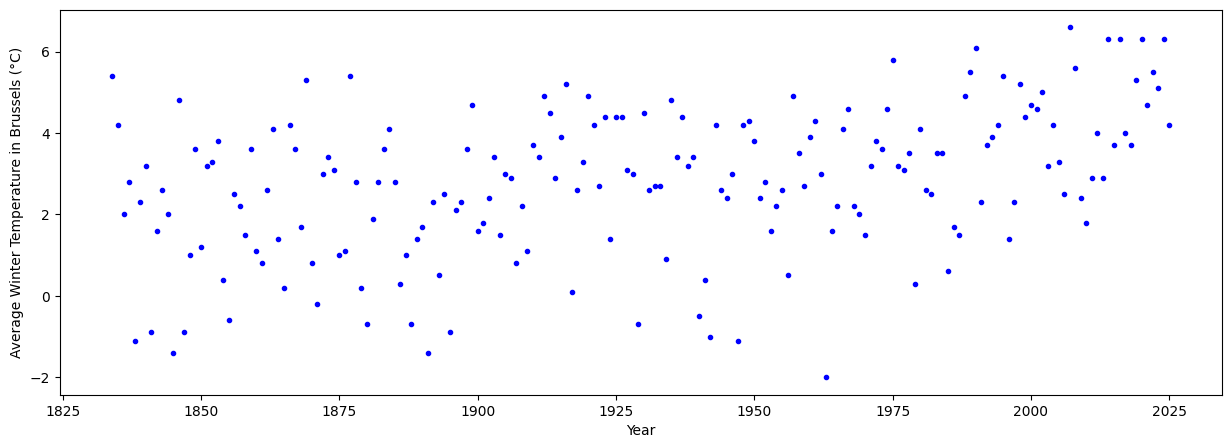

In [10]:
plt.subplots(figsize=(15,5))
plt.plot(temperatures['year'],temperatures['temp'],'b.')
plt.xlabel("Year")
plt.ylabel("Average Winter Temperature in Brussels (°C)")

# 4. Select and Train a Model

We assume their is a linear relationship between the year and the temperature. We can use Linear Regression to find the optimal straight line through the data points. 

Performing Linear Regression using Scikit-Learn is simple:

In [11]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline

# first check just a linear regression without regularization

model = Pipeline([
        ("poly_features", PolynomialFeatures(degree=1, include_bias=False)),
        ("lasso_reg", Lasso(alpha=0.0)),
    ])
model.fit(pd.DataFrame(temperatures['year']), temperatures['temp'])

years = np.array([[1850], [2100]])
temps = model.predict(years)
increase = temps[1] - temps[0]
increase

c:\REPOS\solutions\.venv\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\REPOS\solutions\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\REPOS\solutions\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.585e+02, tolerance: 6.173e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


np.float64(3.2605949732794386)

In [12]:
# find optimal degree and alpha using GridSearchCV
# avoid time-based data leakage by using TimeSeriesSplit for cross-validation
from sklearn.model_selection import TimeSeriesSplit 
'''
The data is divided into 7 consecutive blocks.
Split 1: train on block 1, test on block 2
Split 2: train on blocks 1-2, test on block 3
Split 3: train on blocks 1-3, test on block 4
Split 4: train on blocks 1-4, test on block 5
Split 5: train on blocks 1-5, test on block 6
Split 6: train on blocks 1-6, test on block 7
'''
from sklearn.model_selection import GridSearchCV

param_grid = {
    'poly_features__degree': [1, 2, 3, 4, 5],
    'lasso_reg__alpha': np.arange(0, 10, 1)
}

pipeline = Pipeline([
        ("poly_features", PolynomialFeatures(include_bias=False)),
        ("lasso_reg", Lasso())
    ])

grid_search = GridSearchCV(pipeline, param_grid, cv=TimeSeriesSplit(n_splits=6),scoring='neg_root_mean_squared_error')
grid_search.fit(pd.DataFrame(temperatures['year']), temperatures['temp'])

c:\REPOS\solutions\.venv\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\REPOS\solutions\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\REPOS\solutions\.venv\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\REPOS\solutions\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\REPOS\solutions\.venv\Lib\site-packages\sklearn\l

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...g', Lasso())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lasso_reg__alpha': array([0, 1, ..., 6, 7, 8, 9]), 'poly_features__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time fo

In [13]:
print("Best parameters: {}".format(grid_search.best_params_))
print("Best cross-validation score: {:.2f} °C".format(-grid_search.best_score_))
best_model = grid_search.best_estimator_
print("Best intercept: {}".format(best_model['lasso_reg'].intercept_))
print("Best coefficients: {}".format(best_model['lasso_reg'].coef_))

Best parameters: {'lasso_reg__alpha': np.int64(9), 'poly_features__degree': 4}
Best cross-validation score: 1.66 °C
Best intercept: 28.844025344923658
Best coefficients: [-0.00000000e+00 -2.15540455e-05  4.26818240e-09  1.69015798e-12]


## 5. Use the model

To visualize the model, we use all years between 1830 and 2025

c:\REPOS\solutions\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


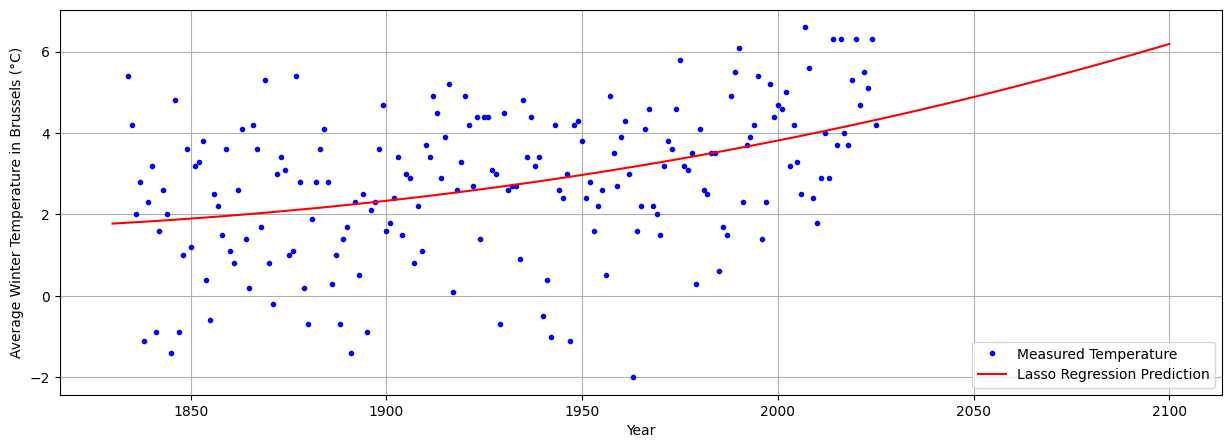

In [15]:
plt.subplots(figsize=(15,5))
plt.plot(temperatures['year'],temperatures['temp'],'b.',label='Measured Temperature')
years = np.arange(1830, 2101)
temps = best_model.predict(years.reshape(-1, 1))
plt.plot(years, temps, "r-",label='Lasso Regression Prediction')
plt.xlabel("Year")
plt.ylabel("Average Winter Temperature in Brussels (°C)")
plt.grid()
plt.legend(loc='lower right')

The central objective of the Paris Agreement is its long-term temperature goal to hold global average temperature increase to “well below 2°C above preindustrial levels and pursuing efforts to limit the temperature increase to 1.5°C above pre-industrial levels”.  (see https://climateactiontracker.org/global/cat-thermometer/)

If we assume 1850 is pre-industrial, by how much will, according to our model, the temperature (Brussels, spring) increase by 2100? 

In [16]:
years = np.array([[1850], [2100]])
temps = best_model.predict(years)
increase = temps[1] - temps[0]
increase

c:\REPOS\solutions\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


np.float64(4.291172217590535)